In [4]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None, rotate=False):
    plt.figure(figsize=(10,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage (%)')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            if rotate:
                ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage (%)')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=hue)
            plt.tight_layout()
            plt.show()

In [6]:
# Load the Parquet file
df = pq.read_table('../../data/health-indicators/can_health_indicator_15-23.parquet').to_pandas()

In [7]:
df.head()

,ref_date,geo,age_group,gender,indicators,unit,value,status,Immunization,Perceived_health,Breastfeeding,BMI,Perceived_mental_health,Chronic_condition,Life_stress,Alcohol_drug_use,Smoking
0,2015,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, very good or excellent",Number_Thousands,17134.3,None,None,very good or excellent,None,None,None,None,None,None,None
1,2015,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, very good or excellent",Percent,61.1,None,None,very good or excellent,None,None,None,None,None,None,None
2,2015,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, fair or poor",Number_Thousands,3167.8,None,None,fair or poor,None,None,None,None,None,None,None
3,2015,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived health, fair or poor",Percent,11.3,None,None,fair or poor,None,None,None,None,None,None,None
4,2015,Canada (excluding territories),"Total, 18 years and over",Both sexes,"Perceived mental health, very good or excellent",Number_Thousands,19683.4,None,None,None,None,None,very good or excellent,None,None,None,None


In [8]:
cat_cols = ['ref_date', 'geo', 'age_group', 'gender']
for col in cat_cols:
    print(df[col].unique())

[2015 2016 2017 2018 2019 2020 2021 2022 2023]
['Canada (excluding territories)' 'Newfoundland and Labrador'
 'Prince Edward Island' 'Nova Scotia' 'New Brunswick' 'Quebec' 'Ontario'
 'Manitoba' 'Saskatchewan' 'Alberta' 'British Columbia']
['Total, 18 years and over' '18 to 34 years' '35 to 49 years'
 '50 to 64 years' '65 years and over']
['Both sexes' 'Males' 'Females']


# Extract Percentages & Counts

In [9]:
percentages = df[df['unit'] == 'Percent']
counts = df[df['unit'] == 'Number_Thousands']

# BMI by Geographic Location

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


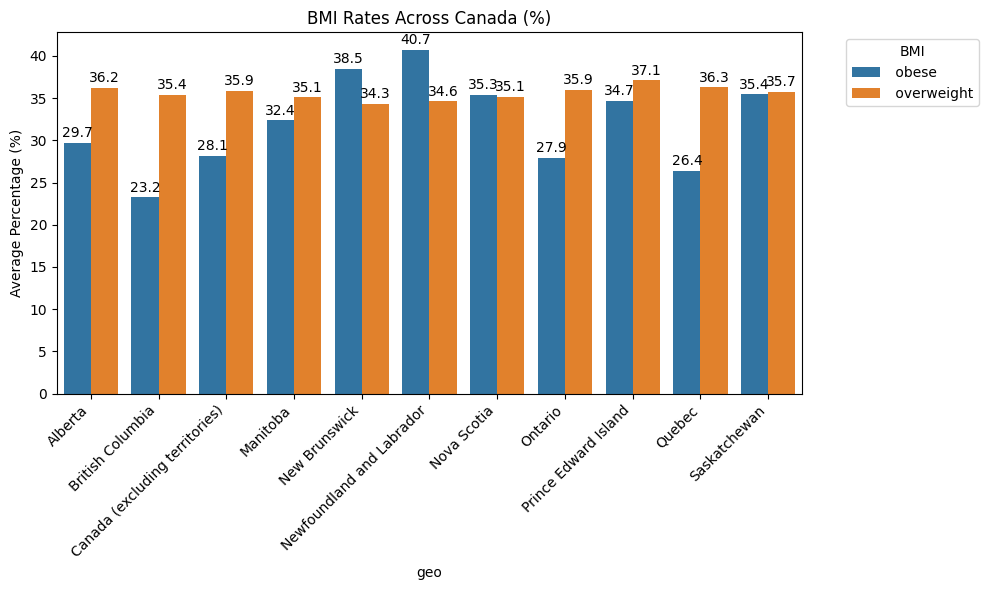

In [10]:
# plot BMI by Geographic Region
plot_bar_chart(percentages, 'geo', 'BMI', "BMI Rates Across Canada (%)", None, stacked_by=False, rotate=45)

# BMI by Gender

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


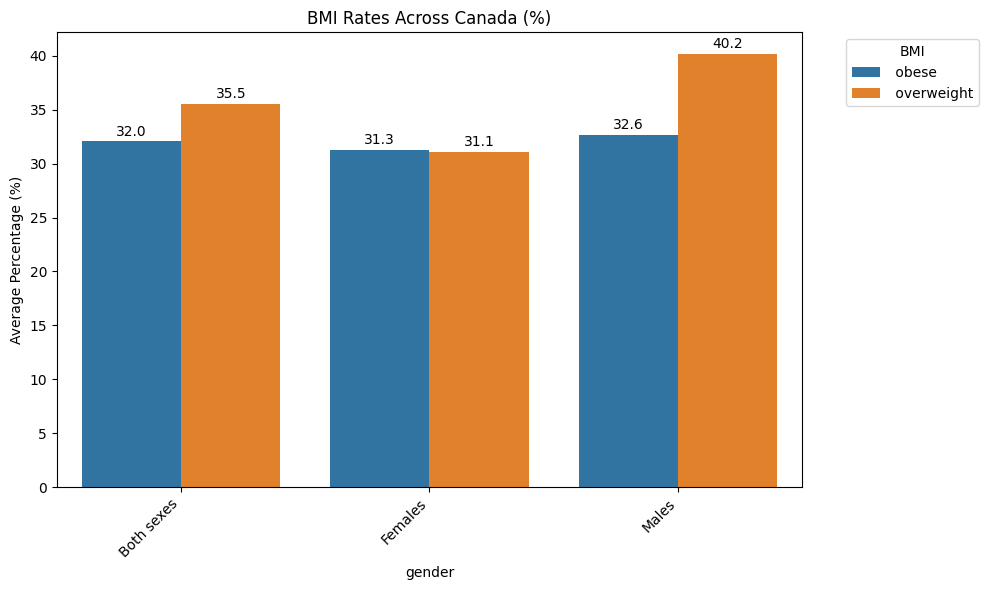

In [11]:
# plot BMI by Gender
plot_bar_chart(percentages, 'gender', 'BMI', "BMI Rates Across Canada (%)", None, stacked_by=False, rotate=45)

# Plots by Gender

In [12]:
cols_to_plot = ['Immunization','Breastfeeding','Life_stress','Perceived_mental_health','Perceived_health','Chronic_condition','Alcohol_drug_use','Smoking']

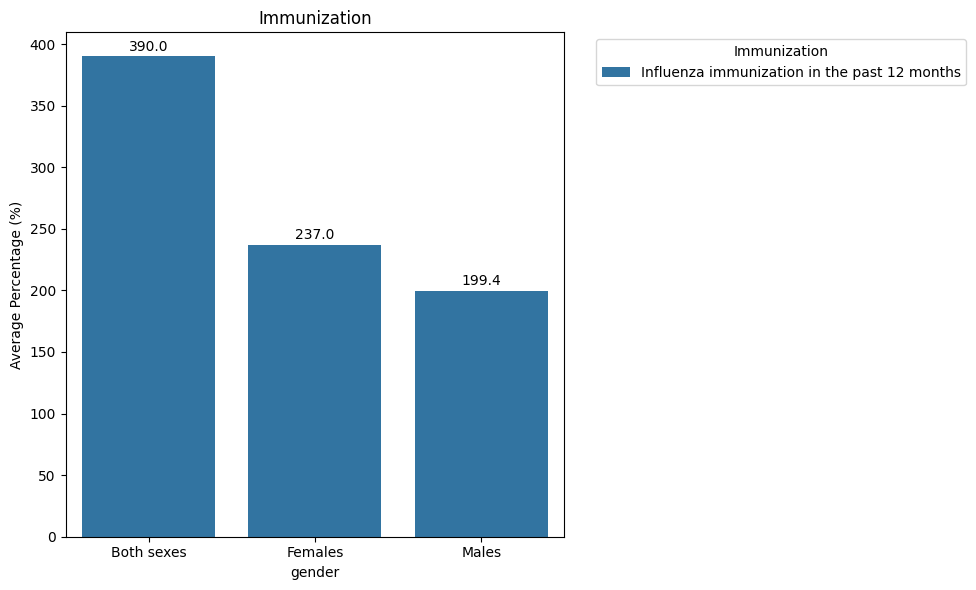

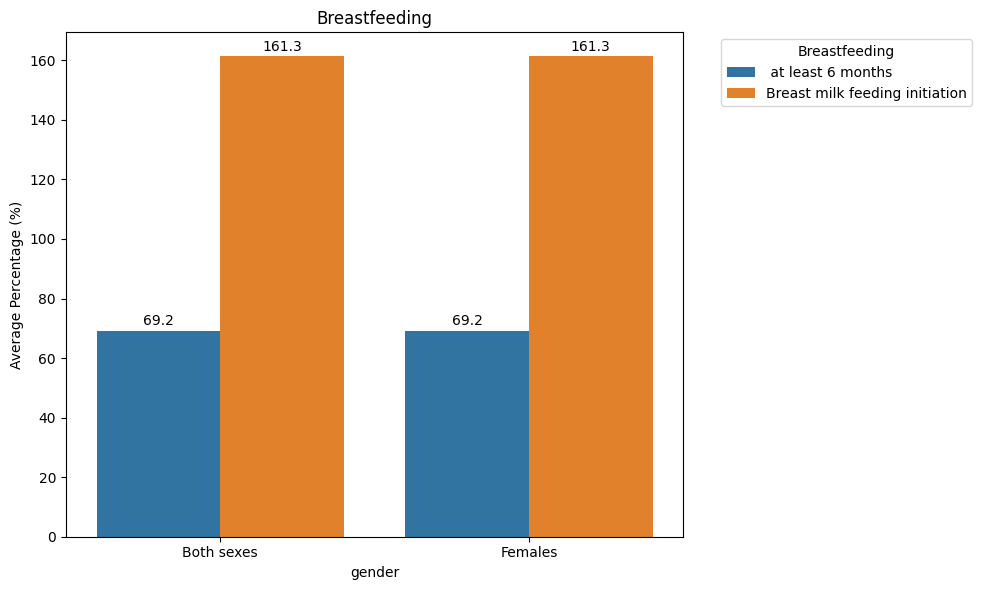

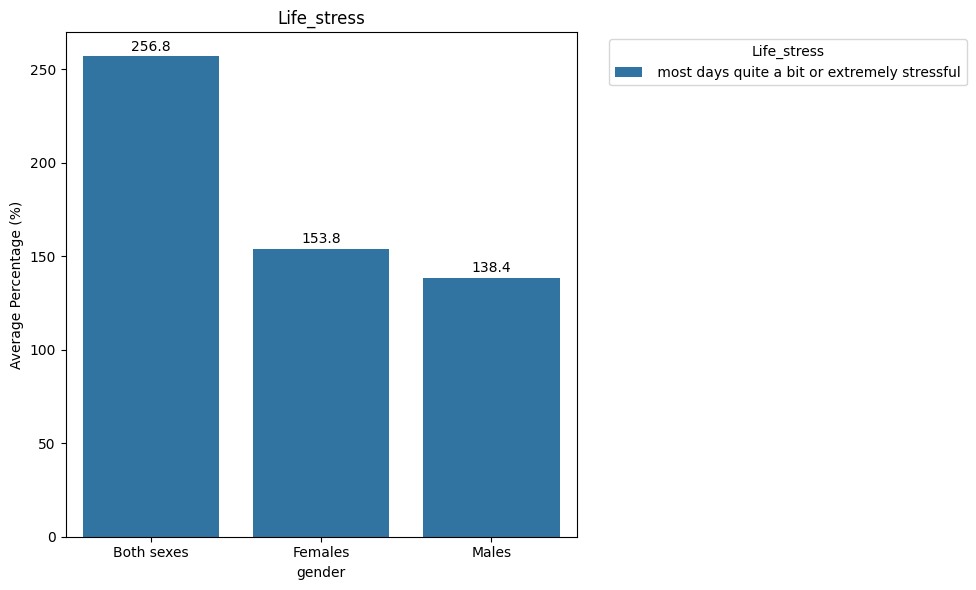

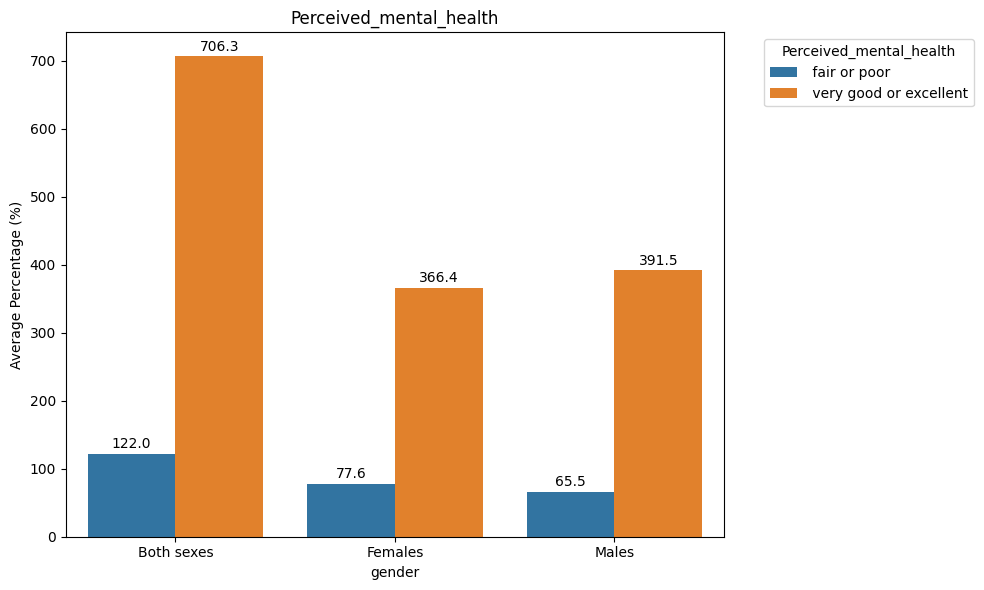

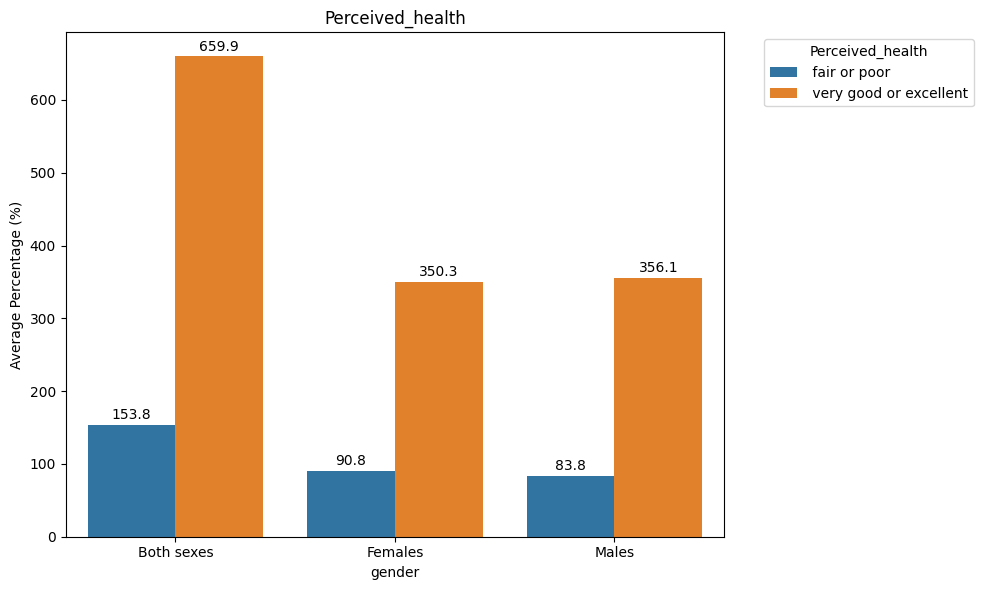

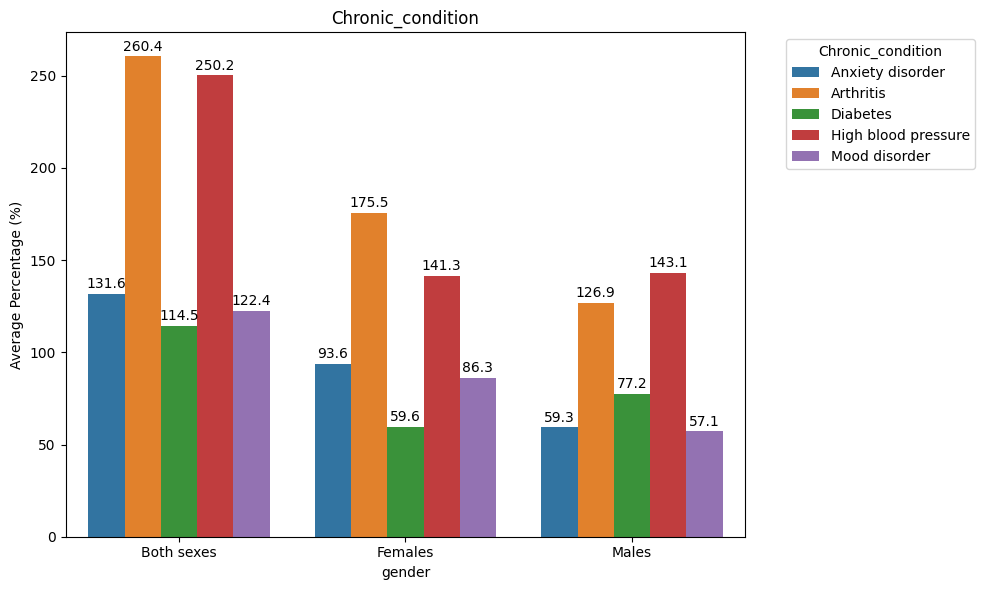

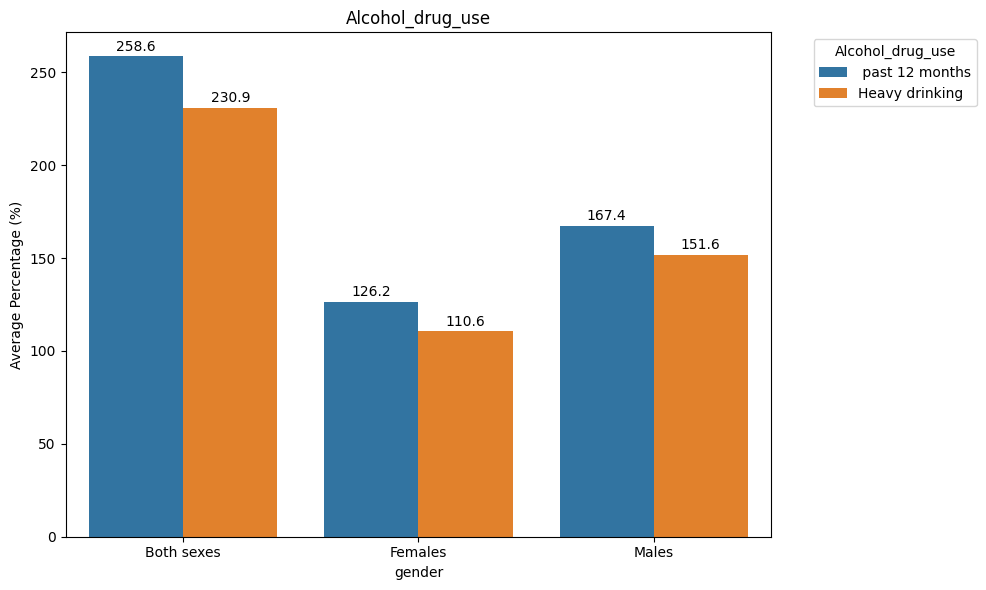

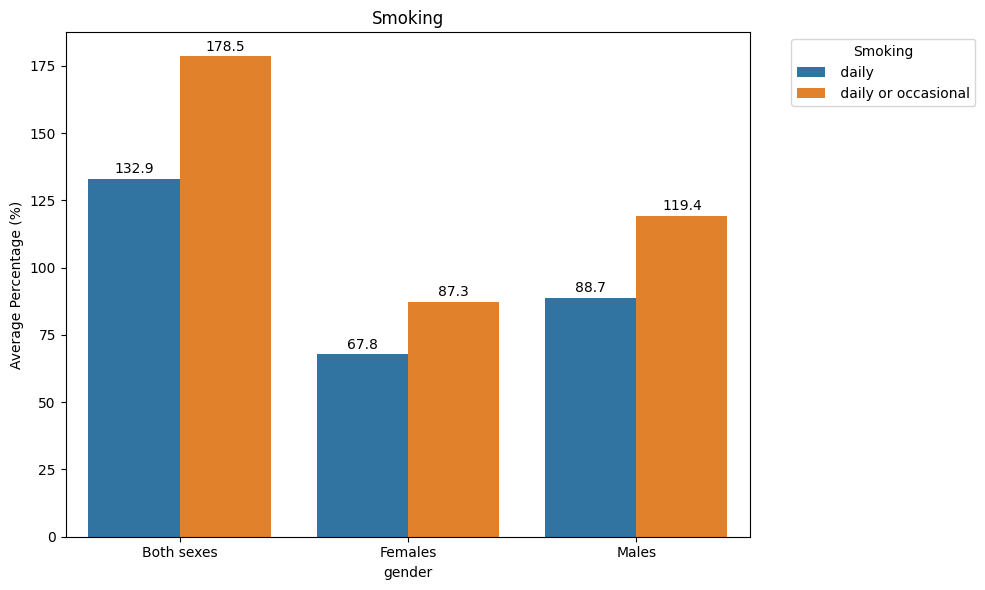

In [13]:
# Plot by Gender
for col in cols_to_plot:
    plot_bar_chart(df, 'gender', col, col, stacked_by=False)

# Plot by Geographic Location

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


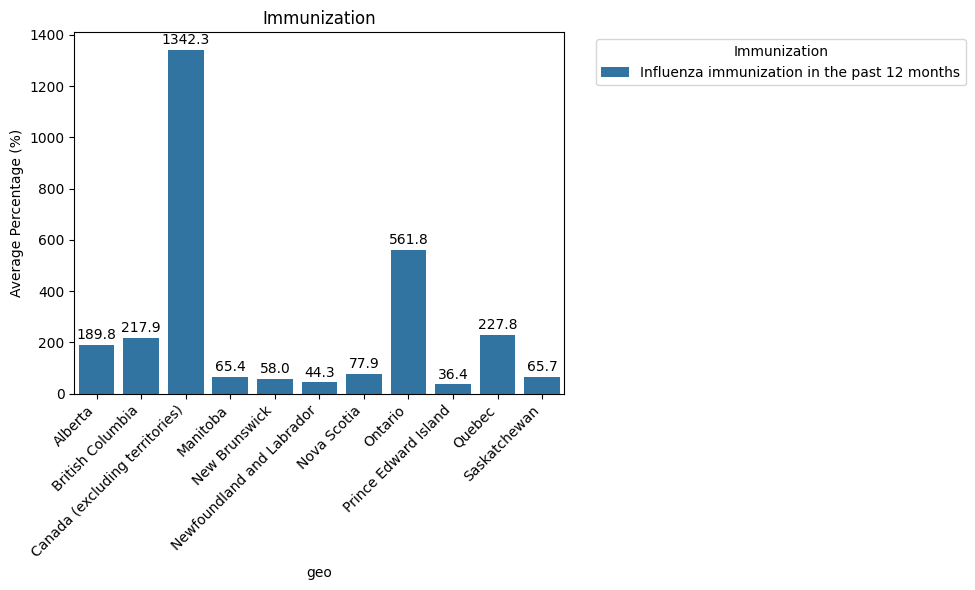

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


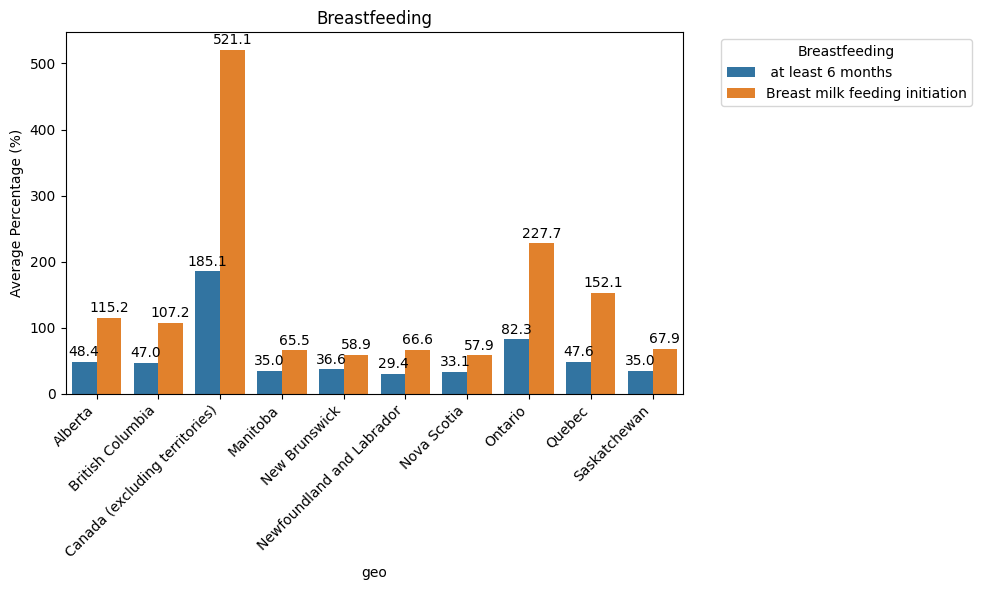

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


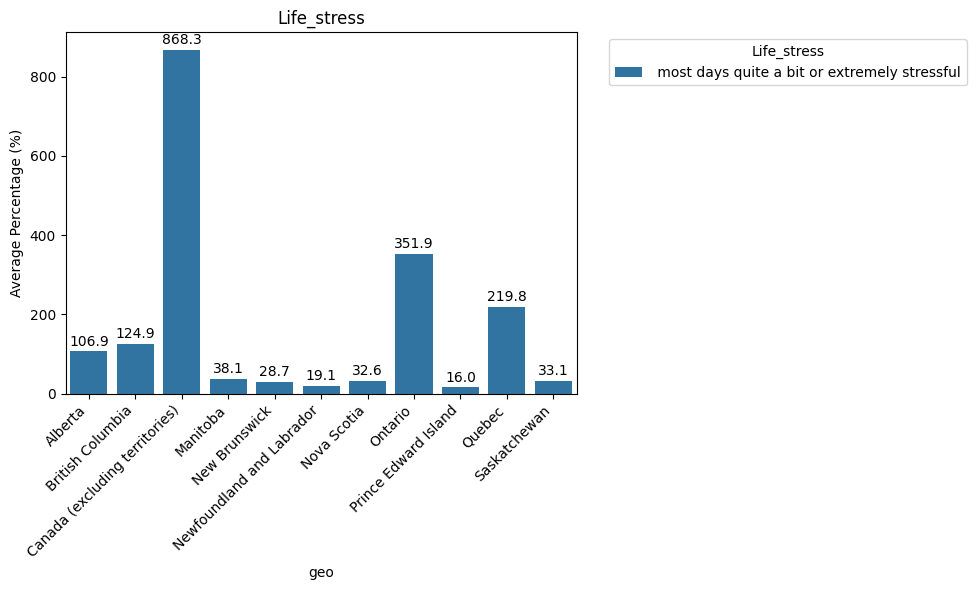

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


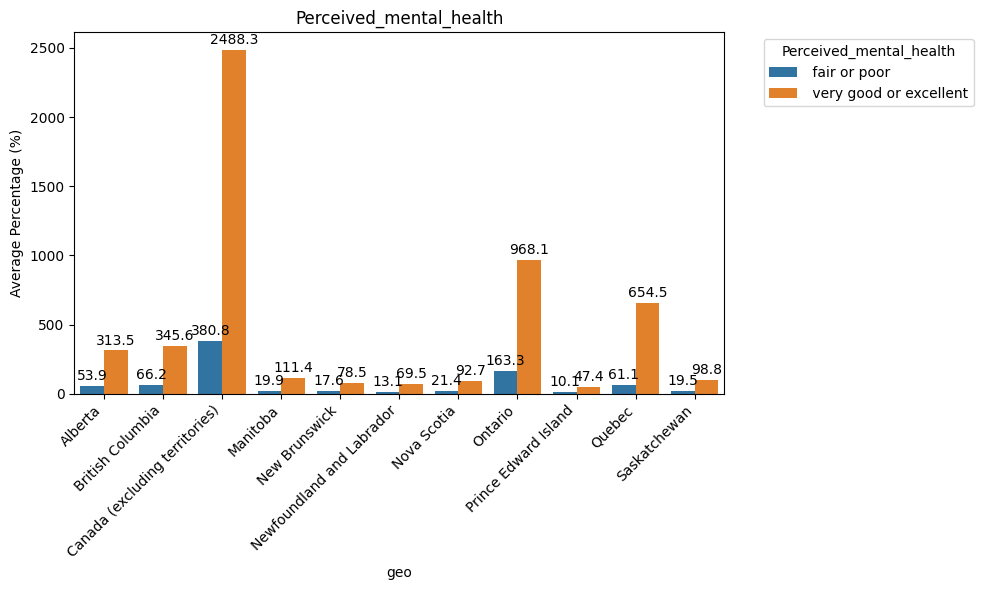

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


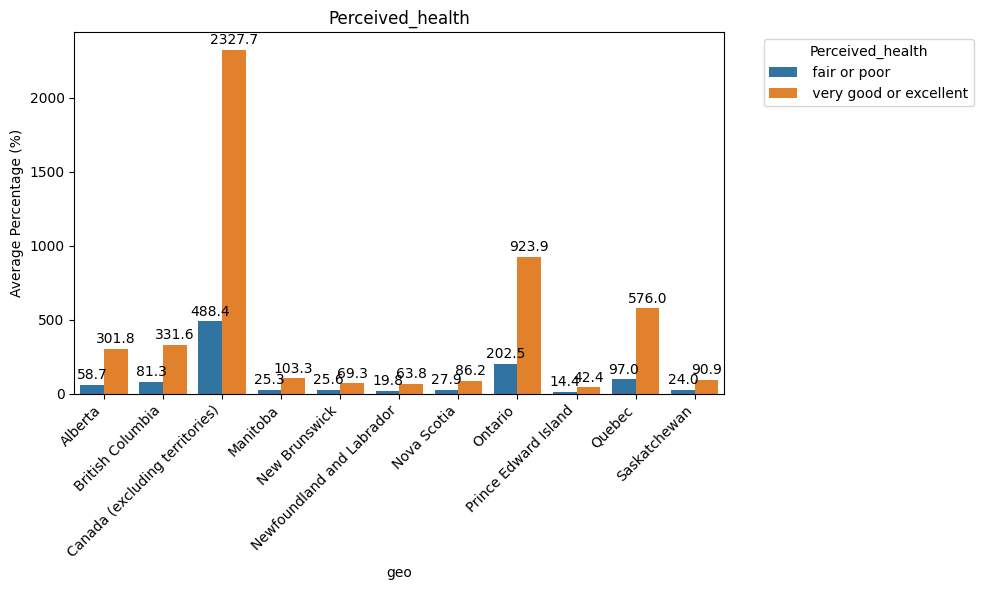

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


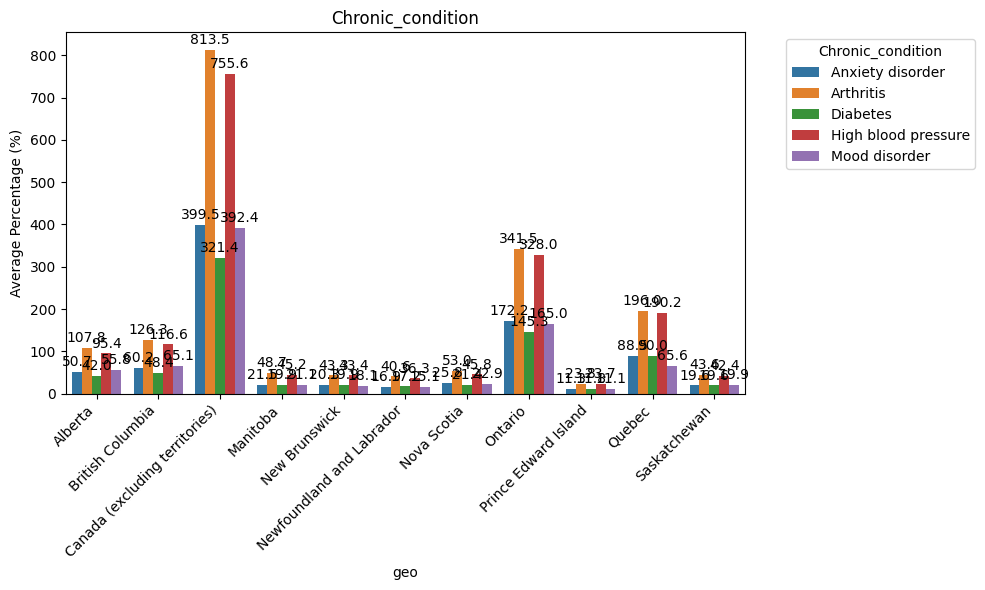

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


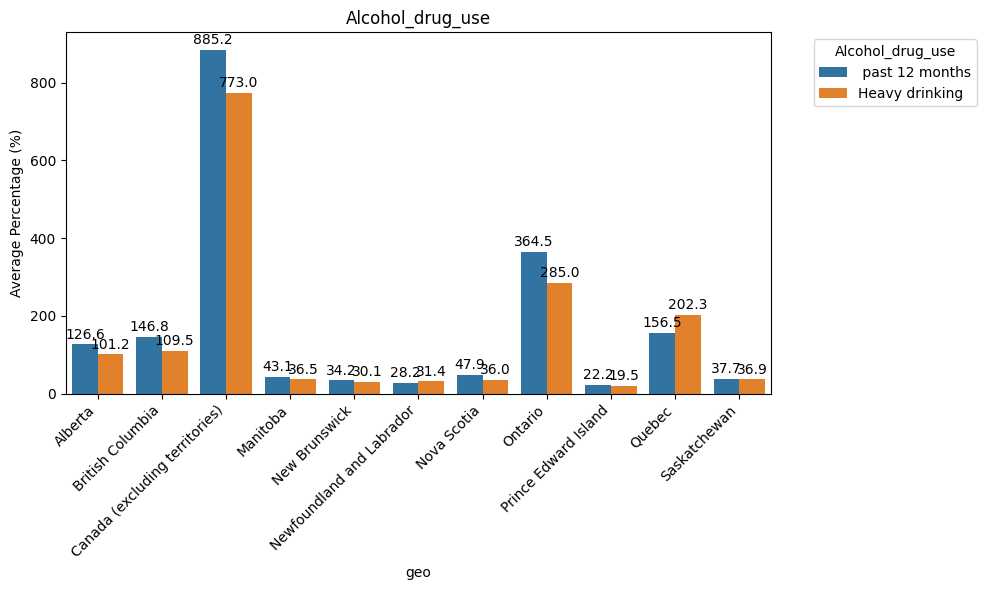

/var/folders/8n/4krln465113bpt4x1bnwnwr80000gn/T/ipykernel_85431/1671836175.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha='right')


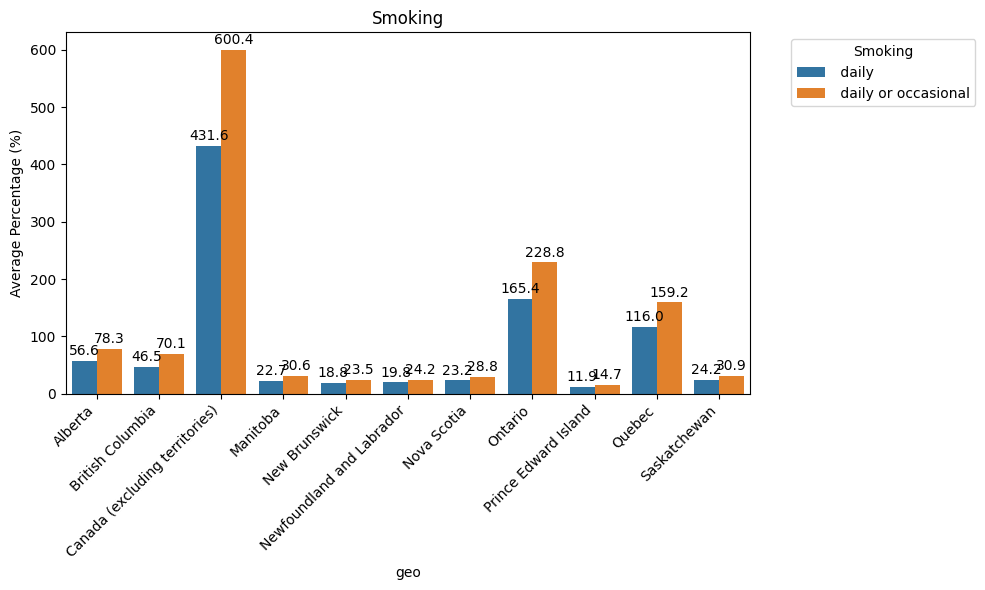

In [14]:
# Plot by Geographic Location
for col in cols_to_plot:
    plot_bar_chart(df, 'geo', col, col, stacked_by=False, rotate=45)